<a href="https://colab.research.google.com/github/lakshlahoti15/MDS_LAB/blob/main/MDS_WEEK_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Operations with NumPy

First, we'll install and import the necessary libraries: `Pillow` for image handling, `matplotlib` for displaying, and `numpy` for array operations.

In [64]:
!pip install Pillow matplotlib numpy

In [65]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

## Load Image

To use your own image, upload it to the Colab environment (e.g., as `my_image.jpg`) using the file explorer on the left. Otherwise, a sample image will be loaded.

Original image shape: (350, 700, 3)


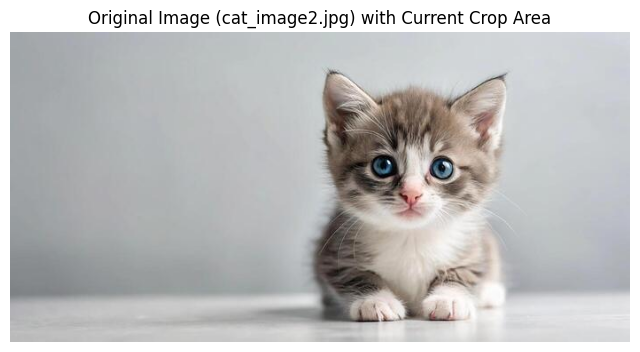

In [66]:
image_path = "cat_image2.jpg" # Changed to your new uploaded image filename

img_pil = Image.open(image_path)

original_image_np = np.array(img_pil)

print(f"Original image shape: {original_image_np.shape}")

plt.figure(figsize=(8, 6))
plt.imshow(original_image_np)
plt.title("Original Image (cat_image2.jpg) with Current Crop Area")
plt.axis('off')

# Draw a rectangle showing the last attempted crop area
# Ensure start_x, start_y, width, height are from the last execution
current_start_x, current_start_y = 440, 140
current_width, current_height = 100, 40



plt.show()

## Crop Image Function

This function crops an image using NumPy slicing.

In [67]:
def crop_image(image_array, start_x, start_y, width, height):
    """Crops an image using NumPy indexing."""
    end_x = start_x + width
    end_y = start_y + height

    # Ensure coordinates are within bounds
    end_y = min(end_y, image_array.shape[0])
    end_x = min(end_x, image_array.shape[1])

    return image_array[start_y:end_y, start_x:end_x]

### Crop Demonstration

Let's crop a part of the image.

Cropped image shape: (80, 80, 3)


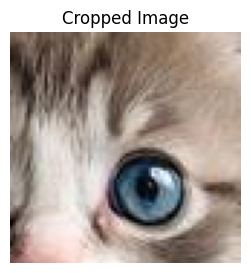

In [80]:
start_x, start_y = 440, 100  # Adjusted coordinates to target a more distinct eye area
width, height = 80, 80    # Adjusted for a more square crop to capture an entire eye

cropped_image = crop_image(original_image_np, start_x, start_y, width, height)

print(f"Cropped image shape: {cropped_image.shape}")

plt.figure(figsize=(4, 3))
plt.imshow(cropped_image)
plt.title("Cropped Image")
plt.axis('off')
plt.show()

## Flip Image Function

This function flips an image horizontally or vertically using NumPy slicing.

In [69]:
def flip_image(image_array, axis='horizontal'):
    """Flips an image using NumPy indexing."""
    if axis == 'horizontal':
        return image_array[:, ::-1]
    elif axis == 'vertical':
        return image_array[::-1, :]
    else:
        raise ValueError("Axis must be 'horizontal' or 'vertical'.")

### Flip Demonstration

See the image flipped horizontally and vertically.

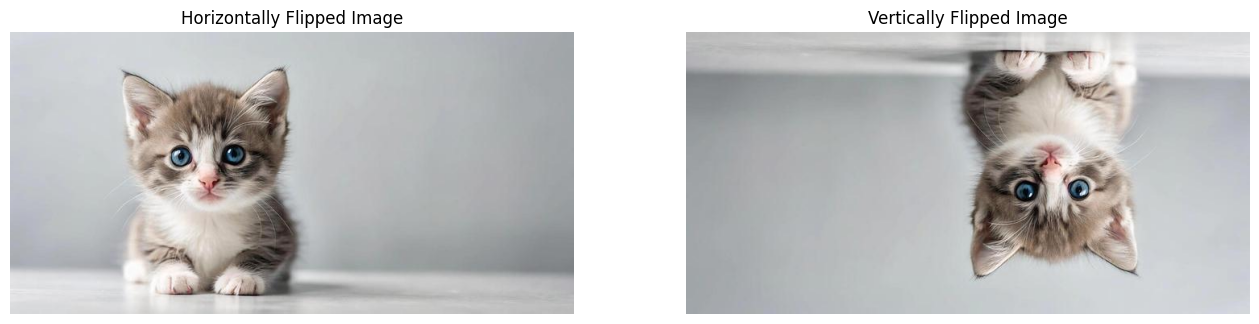

In [70]:
horizontal_flipped_image = flip_image(original_image_np, axis='horizontal')
vertical_flipped_image = flip_image(original_image_np, axis='vertical')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(horizontal_flipped_image)
axes[0].set_title("Horizontally Flipped Image")
axes[0].axis('off')

axes[1].imshow(vertical_flipped_image)
axes[1].set_title("Vertically Flipped Image")
axes[1].axis('off')

plt.show()

## Rotate Image Function

This function rotates an image using NumPy's `rot90` function.

In [71]:
def rotate_image(image_array, degrees):
    """Rotates an image by 90, 180, or 270 degrees using NumPy's rot90."""
    if degrees == 90:
        return np.rot90(image_array, k=1) # Rotate 90 degrees clockwise
    elif degrees == 180:
        return np.rot90(image_array, k=2) # Rotate 180 degrees
    elif degrees == 270:
        return np.rot90(image_array, k=3) # Rotate 270 degrees clockwise (or 90 counter-clockwise)
    else:
        raise ValueError("Degrees must be 90, 180, or 270.")

### Rotate Demonstration

Let's see the image rotated 90 and 270 degrees.

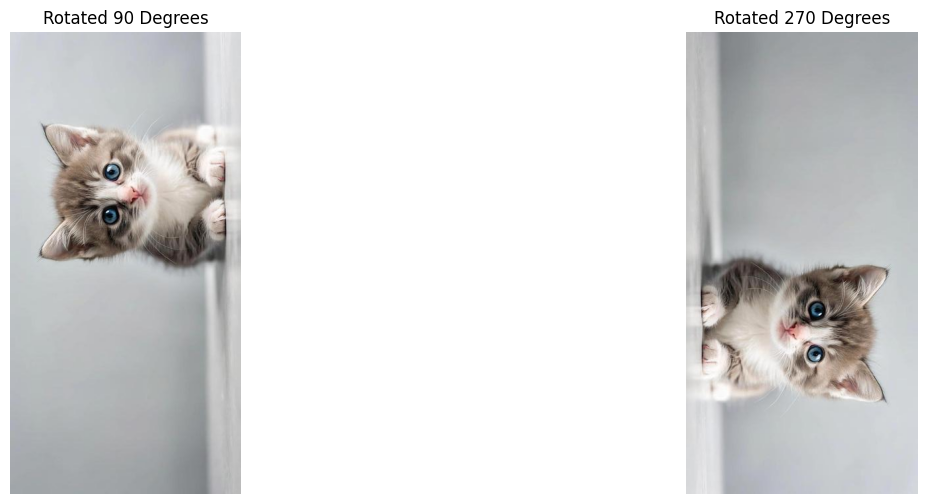

In [72]:
rotated_90_image = rotate_image(original_image_np, degrees=90)
rotated_270_image = rotate_image(original_image_np, degrees=270)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(rotated_90_image)
axes[0].set_title("Rotated 90 Degrees")
axes[0].axis('off')

axes[1].imshow(rotated_270_image)
axes[1].set_title("Rotated 270 Degrees")
axes[1].axis('off')

plt.show()

## Convert to OpenCV and show RGB vs BGR

First, let's install the `opencv-python` library.

In [73]:
!pip install opencv-python

Now, let's import OpenCV and convert the `original_image_np` (which is in RGB) to BGR, which is OpenCV's default format. We'll then display both to illustrate the channel order difference.

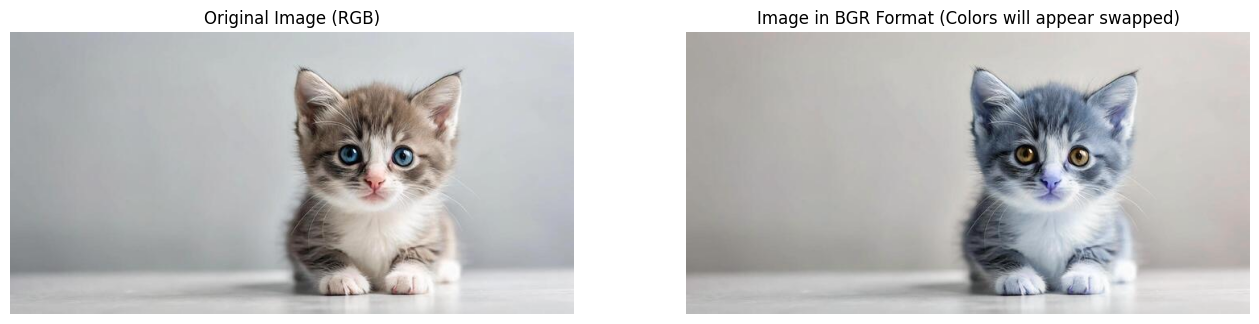

Note: The 'Image in BGR Format' appears with swapped colors (blue appears red, red appears blue) because `matplotlib.pyplot.imshow` interprets the channel order as RGB, while `image_bgr` is in BGR.


In [74]:
import cv2

# Convert the original NumPy array (which is RGB from PIL) to BGR for OpenCV
image_bgr = cv2.cvtColor(original_image_np, cv2.COLOR_RGB2BGR)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(original_image_np)
axes[0].set_title("Original Image (RGB)")
axes[0].axis('off')

# Display the BGR image directly. Matplotlib's imshow expects RGB, so colors will be swapped.
axes[1].imshow(image_bgr)
axes[1].set_title("Image in BGR Format (Colors will appear swapped)")
axes[1].axis('off')

plt.show()

print("Note: The 'Image in BGR Format' appears with swapped colors (blue appears red, red appears blue) because `matplotlib.pyplot.imshow` interprets the channel order as RGB, while `image_bgr` is in BGR.")

## Load CSV and Perform Operations

First, let's load the `Simple 100 Student Marks.csv` file into a pandas DataFrame.

In [75]:
import pandas as pd

csv_file_path = '/content/Simple 100 Student Marks.csv'
df_students = pd.read_csv(csv_file_path)

print(f"CSV file '{csv_file_path}' loaded successfully.")
display(df_students.head())

CSV file '/content/Simple 100 Student Marks.csv' loaded successfully.


,student_name,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
0,Mr. Gregory Homenick,69,24,52,4,83
1,Marlene Leffler IV,62,59,70,54,52
2,Josephine Ebert,29,76,13,8,19
3,Dr. Irene Green,44,66,14,2,14
4,Jake Huel,49,23,63,86,68


### Statistical Operations: Descriptive Statistics

Let's calculate and display the descriptive statistics for all numerical columns (student marks) in the DataFrame.

In [76]:
# Display descriptive statistics for numerical columns
display(df_students.describe())

,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
count,100.000000,100.000000,100.00000,100.000000,100.000000
mean,48.950000,56.010000,52.48000,51.510000,46.180000
std,28.999956,26.487846,27.02542,29.081041,23.590522
min,2.000000,4.000000,1.00000,2.000000,3.000000
25%,27.000000,39.500000,32.00000,29.250000,27.000000
50%,52.500000,59.000000,51.00000,52.500000,42.500000
75%,70.250000,76.000000,76.00000,77.000000,65.000000
max,100.000000,99.000000,97.00000,100.000000,98.000000


### Statistical Operations: Calculate Total Marks per Student

Let's calculate the total marks for each student and add it as a new column, then display the students with their total marks.

In [77]:
# Identify mark columns
mark_columns = ['maths_marks', 'science_marks', 'english_marks', 'social_studies_marks', 'language_marks']

# Calculate total marks for each student
df_students['total_marks'] = df_students[mark_columns].sum(axis=1)

# Display the DataFrame with the new 'total_marks' column, sorted by total marks
display(df_students.sort_values(by='total_marks', ascending=False).head())

,student_name,maths_marks,science_marks,english_marks,social_studies_marks,language_marks,total_marks
39,Lowell Bartell,94,67,63,87,87,398
86,Matthew MacGyver,94,59,91,74,78,396
67,Andres Lemke,97,78,64,64,82,385
21,Edith Gorczany,60,48,94,71,98,371
66,Carole Lubowitz,54,95,79,97,43,368


### Statistical Operations: Average Marks per Subject

Let's calculate the average mark for each subject.

In [78]:
# Calculate average marks for each subject
average_marks_per_subject = df_students[mark_columns].mean()

print("Average marks per subject:")
display(average_marks_per_subject)

Average marks per subject:


,0
maths_marks,48.95
science_marks,56.01
english_marks,52.48
social_studies_marks,51.51
language_marks,46.18


### Create Pandas Series and DataFrame from various inputs

#### 1. Create a Series from a list

In [81]:
# Create a Series from a list
s = pd.Series([10, 20, 30, 40, 50])
print("Series from a list:")
display(s)

Series from a list:


,0
0,10
1,20
2,30
3,40
4,50


#### 2. Create a Series from a dictionary

In [82]:
# Create a Series from a dictionary
data_dict_series = {'a': 100, 'b': 200, 'c': 300}
s_dict = pd.Series(data_dict_series)
print("\nSeries from a dictionary:")
display(s_dict)


Series from a dictionary:


,0
a,100
b,200
c,300


#### 3. Create a DataFrame from a dictionary of lists (column-wise)

In [83]:
# Create a DataFrame from a dictionary of lists (column-wise)
data_df_dict = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [25, 30, 35, 40],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston']
}
df_from_dict = pd.DataFrame(data_df_dict)
print("\nDataFrame from a dictionary of lists:")
display(df_from_dict)


DataFrame from a dictionary of lists:


,Name,Age,City
0,Alice,25,New York
1,Bob,30,Los Angeles
2,Charlie,35,Chicago
3,David,40,Houston


#### 4. Create a DataFrame from a list of dictionaries (row-wise)

In [84]:
# Create a DataFrame from a list of dictionaries (row-wise)
data_list_dict = [
    {'Name': 'Eve', 'Age': 28, 'City': 'Miami'},
    {'Name': 'Frank', 'Age': 32, 'City': 'Seattle'},
    {'Name': 'Grace', 'Age': 22, 'City': 'Boston'}
]
df_from_list_of_dict = pd.DataFrame(data_list_dict)
print("\nDataFrame from a list of dictionaries:")
display(df_from_list_of_dict)


DataFrame from a list of dictionaries:


,Name,Age,City
0,Eve,28,Miami
1,Frank,32,Seattle
2,Grace,22,Boston


#### 5. Create a DataFrame from a NumPy array

In [85]:
# Create a DataFrame from a NumPy array
numpy_array = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
df_from_numpy = pd.DataFrame(numpy_array, columns=['ColA', 'ColB', 'ColC'])
print("\nDataFrame from a NumPy array:")
display(df_from_numpy)


DataFrame from a NumPy array:


,ColA,ColB,ColC
0,1,2,3
1,4,5,6
2,7,8,9


---

## Pandas DataFrame Operations on Cricket Player Stats

First, let's load the `cricket_player_stats.csv.zip` file. Since it's a zip file, `pandas.read_csv` can handle it directly.

In [86]:
import pandas as pd

cricket_csv_path = '/content/cricket_player_stats.csv.zip'
df_cricket = pd.read_csv(cricket_csv_path)

print(f"CSV file '{cricket_csv_path}' loaded successfully.")
display(df_cricket.head())

CSV file '/content/cricket_player_stats.csv.zip' loaded successfully.


,Unnamed: 0,name,team,date_of_birth,BT_Test_M,BT_Test_Inn,BT_Test_NO,BT_Test_Runs,BT_Test_HS,BT_Test_Avg,...,BW_T20I_Inn,BW_T20I_B,BW_T20I_Runs,BW_T20I_Wkts,BW_T20I_BBM,BW_T20I_Econ,BW_T20I_Avg,BW_T20I_SR,BW_T20I_5W,BW_T20I_10W
0,0,Sachin Tendulkar,India,"Apr 24, 1973 (49 years)",200,329,33,15921,248,53.79,...,1,15,12,1,1 for 12,4.8,12.0,15.0,0,0
1,1,Virender Sehwag,India,"Oct 20, 1978 (44 years)",104,180,6,8586,319,49.34,...,1,6,20,0,0 for 20,20.0,0.0,0.0,0,0
2,2,Rahul Dravid,India,"Jan 11, 1973 (49 years)",164,286,32,13288,270,52.31,...,0,0,0,0,0,0.0,0.0,0.0,0,0
3,3,VVS Laxman,India,"Nov 01, 1974 (48 years)",134,225,32,8781,281,45.50,...,0,0,0,0,0,0.0,0.0,0.0,0,0
4,4,Sourav Ganguly,India,"Jul 08, 1972 (50 years)",113,188,17,7212,239,42.18,...,0,0,0,0,0,0.0,0.0,0.0,0,0


### (a) Visualize the first and last 10 records

#### First 10 records

In [87]:
# Display the first 10 records
print("First 10 records of the DataFrame:")
display(df_cricket.head(10))

First 10 records of the DataFrame:


,Unnamed: 0,name,team,date_of_birth,BT_Test_M,BT_Test_Inn,BT_Test_NO,BT_Test_Runs,BT_Test_HS,BT_Test_Avg,...,BW_T20I_Inn,BW_T20I_B,BW_T20I_Runs,BW_T20I_Wkts,BW_T20I_BBM,BW_T20I_Econ,BW_T20I_Avg,BW_T20I_SR,BW_T20I_5W,BW_T20I_10W
0,0,Sachin Tendulkar,India,"Apr 24, 1973 (49 years)",200,329,33,15921,248,53.79,...,1,15,12,1,1 for 12,4.80,12.00,15.00,0,0
1,1,Virender Sehwag,India,"Oct 20, 1978 (44 years)",104,180,6,8586,319,49.34,...,1,6,20,0,0 for 20,20.00,0.00,0.00,0,0
2,2,Rahul Dravid,India,"Jan 11, 1973 (49 years)",164,286,32,13288,270,52.31,...,0,0,0,0,0,0.00,0.00,0.00,0,0
3,3,VVS Laxman,India,"Nov 01, 1974 (48 years)",134,225,32,8781,281,45.50,...,0,0,0,0,0,0.00,0.00,0.00,0,0
4,4,Sourav Ganguly,India,"Jul 08, 1972 (50 years)",113,188,17,7212,239,42.18,...,0,0,0,0,0,0.00,0.00,0.00,0,0
5,5,Shoaib Akhtar,Pakistan,"Aug 13, 1975 (47 years)",46,67,13,544,47,10.07,...,15,318,432,19,3 for 38,8.15,22.74,16.74,0,0
6,6,Mohammad Sami,Pakistan,"Feb 24, 1981 (41 years)",36,56,14,487,49,11.60,...,13,276,387,21,3 for 16,8.41,18.43,13.14,0,0
7,7,Shabbir Ahmed,Pakistan,"Apr 21, 1976 (46 years)",10,15,5,88,24,8.80,...,1,12,19,0,0 for 19,9.50,0.00,0.00,0,0
8,8,Shoaib Malik,Pakistan,"Feb 01, 1982 (40 years)",35,60,6,1898,245,35.15,...,50,570,675,28,2 for 7,7.11,24.11,20.36,0,0
9,9,Mohammad Yousuf,Pakistan,"Aug 27, 1974 (48 years)",90,156,12,7530,223,52.29,...,0,0,0,0,0,0.00,0.00,0.00,0,0


#### Last 10 records

In [88]:
# Display the last 10 records
print("Last 10 records of the DataFrame:")
display(df_cricket.tail(10))

Last 10 records of the DataFrame:


,Unnamed: 0,name,team,date_of_birth,BT_Test_M,BT_Test_Inn,BT_Test_NO,BT_Test_Runs,BT_Test_HS,BT_Test_Avg,...,BW_T20I_Inn,BW_T20I_B,BW_T20I_Runs,BW_T20I_Wkts,BW_T20I_BBM,BW_T20I_Econ,BW_T20I_Avg,BW_T20I_SR,BW_T20I_5W,BW_T20I_10W
5707,5707,Yasin Patel,Kuwait,"Aug 28, 1997 (25 years)",0,0,0,0,0,0.0,...,6,144,138,8,4 for 22,5.75,17.25,18.0,0,0
5708,5708,Janaka Chaturanga,Bahrain,"Sep 23, 1982 (40 years)",0,0,0,0,0,0.0,...,0,0,0,0,0,0.00,0.00,0.0,0,0
5709,5709,Umer Toor,Bahrain,"Apr 09, 1991 (31 years)",0,0,0,0,0,0.0,...,0,0,0,0,0,0.00,0.00,0.0,0,0
5710,5710,Naveen Thailappan,Bahrain,"May 17, 1992 (30 years)",0,0,0,0,0,0.0,...,2,42,82,1,1 for 42,11.71,82.00,42.0,0,0
5711,5711,Sachin Kumar,Bahrain,"Apr 03, 1989 (33 years)",0,0,0,0,0,0.0,...,8,138,192,5,2 for 27,8.35,38.40,27.6,0,0
5712,5712,Imran Khan,Bahrain,"Apr 01, 1990 (32 years)",0,0,0,0,0,0.0,...,7,150,202,5,4 for 16,8.08,40.40,30.0,0,0
5713,5713,Shahrukh Quddus,Kuwait,"Dec 11, 1996 (26 years)",0,0,0,0,0,0.0,...,1,24,14,3,3 for 14,3.50,4.67,8.0,0,0
5714,5714,Ateeq Iqbal,Hong Kong,"Dec 10, 1991 (31 years)",0,0,0,0,0,0.0,...,1,6,6,0,0 for 6,6.00,0.00,0.0,0,0
5715,5715,Ali Zaheer,Kuwait,"Feb 08, 1994 (28 years)",0,0,0,0,0,0.0,...,0,0,0,0,0,0.00,0.00,0.0,0,0
5716,5716,Adwitya Bhargava,Singapore,--,0,0,0,0,0,0.0,...,1,12,14,1,1 for 14,7.00,14.00,12.0,0,0


### (b) Get the shape, index, and column details

#### Get the shape of the DataFrame

In [89]:
# Get the shape of the DataFrame (rows, columns)
print("Shape of the DataFrame (rows, columns):")
display(df_cricket.shape)

Shape of the DataFrame (rows, columns):


(5717, 77)

#### Get the index details of the DataFrame

In [90]:
# Get the index details
print("Index details of the DataFrame:")
display(df_cricket.index)

Index details of the DataFrame:


RangeIndex(start=0, stop=5717, step=1)

#### Get the column details of the DataFrame

In [91]:
# Get the column details
print("Column details of the DataFrame:")
display(df_cricket.columns)

Column details of the DataFrame:


Index(['Unnamed: 0', 'name', 'team', 'date_of_birth', 'BT_Test_M',
       'BT_Test_Inn', 'BT_Test_NO', 'BT_Test_Runs', 'BT_Test_HS',
       'BT_Test_Avg', 'BT_Test_BF', 'BT_Test_SR', 'BT_Test_100', 'BT_Test_200',
       'BT_Test_50', 'BT_Test_4s', 'BT_Test_6s', 'BT_ODI_M', 'BT_ODI_Inn',
       'BT_ODI_NO', 'BT_ODI_Runs', 'BT_ODI_HS', 'BT_ODI_Avg', 'BT_ODI_BF',
       'BT_ODI_SR', 'BT_ODI_100', 'BT_ODI_200', 'BT_ODI_50', 'BT_ODI_4s',
       'BT_ODI_6s', 'BT_T20I_M', 'BT_T20I_Inn', 'BT_T20I_NO', 'BT_T20I_Runs',
       'BT_T20I_HS', 'BT_T20I_Avg', 'BT_T20I_BF', 'BT_T20I_SR', 'BT_T20I_100',
       'BT_T20I_200', 'BT_T20I_50', 'BT_T20I_4s', 'BT_T20I_6s', 'BW_Test_M',
       'BW_Test_Inn', 'BW_Test_B', 'BW_Test_Runs', 'BW_Test_Wkts',
       'BW_Test_BBI', 'BW_Test_BBM', 'BW_Test_Econ', 'BW_Test_Avg',
       'BW_Test_SR', 'BW_Test_5W', 'BW_Test_10W', 'BW_ODI_M', 'BW_ODI_Inn',
       'BW_ODI_B', 'BW_ODI_Runs', 'BW_ODI_Wkts', 'BW_ODI_BBM', 'BW_ODI_Econ',
       'BW_ODI_Avg', 'BW_ODI_SR', 'BW_OD

#### Delete records (rows) based on conditions

In [94]:
# To avoid modifying the original DataFrame directly, let's create a copy.
df_cricket_modified = df_cricket.copy()

# Delete records (rows) where 'BT_Test_M' (Test Matches played) is 0
initial_rows = df_cricket_modified.shape[0]
df_cricket_modified = df_cricket_modified[df_cricket_modified['BT_Test_M'] > 0]

print(f"Initial number of rows: {initial_rows}")
print(f"Number of rows after deleting players with 0 Test Matches: {df_cricket_modified.shape[0]}")
print("First 5 records after deletion:")
display(df_cricket_modified.head())

Initial number of rows: 5717
Number of rows after deleting players with 0 Test Matches: 3089
First 5 records after deletion:


,Unnamed: 0,name,team,date_of_birth,BT_Test_M,BT_Test_Inn,BT_Test_NO,BT_Test_Runs,BT_Test_HS,BT_Test_Avg,...,BW_T20I_Inn,BW_T20I_B,BW_T20I_Runs,BW_T20I_Wkts,BW_T20I_BBM,BW_T20I_Econ,BW_T20I_Avg,BW_T20I_SR,BW_T20I_5W,BW_T20I_10W
0,0,Sachin Tendulkar,India,"Apr 24, 1973 (49 years)",200,329,33,15921,248,53.79,...,1,15,12,1,1 for 12,4.8,12.0,15.0,0,0
1,1,Virender Sehwag,India,"Oct 20, 1978 (44 years)",104,180,6,8586,319,49.34,...,1,6,20,0,0 for 20,20.0,0.0,0.0,0,0
2,2,Rahul Dravid,India,"Jan 11, 1973 (49 years)",164,286,32,13288,270,52.31,...,0,0,0,0,0,0.0,0.0,0.0,0,0
3,3,VVS Laxman,India,"Nov 01, 1974 (48 years)",134,225,32,8781,281,45.50,...,0,0,0,0,0,0.0,0.0,0.0,0,0
4,4,Sourav Ganguly,India,"Jul 08, 1972 (50 years)",113,188,17,7212,239,42.18,...,0,0,0,0,0,0.0,0.0,0.0,0,0


#### Delete columns

In [95]:
# Drop the 'Unnamed: 0' column as it often represents an unnecessary index column from CSV export
# We'll work with a fresh copy to demonstrate this clearly
df_cricket_cols_dropped = df_cricket.copy()

print(f"Columns before dropping: {df_cricket_cols_dropped.columns.tolist()[:5]}...") # Display first 5 cols

df_cricket_cols_dropped = df_cricket_cols_dropped.drop(columns=['Unnamed: 0'])

print(f"Columns after dropping 'Unnamed: 0': {df_cricket_cols_dropped.columns.tolist()[:5]}...") # Display first 5 cols
print("DataFrame head after column deletion:")
display(df_cricket_cols_dropped.head())

Columns before dropping: ['Unnamed: 0', 'name', 'team', 'date_of_birth', 'BT_Test_M']...
Columns after dropping 'Unnamed: 0': ['name', 'team', 'date_of_birth', 'BT_Test_M', 'BT_Test_Inn']...
DataFrame head after column deletion:


,name,team,date_of_birth,BT_Test_M,BT_Test_Inn,BT_Test_NO,BT_Test_Runs,BT_Test_HS,BT_Test_Avg,BT_Test_BF,...,BW_T20I_Inn,BW_T20I_B,BW_T20I_Runs,BW_T20I_Wkts,BW_T20I_BBM,BW_T20I_Econ,BW_T20I_Avg,BW_T20I_SR,BW_T20I_5W,BW_T20I_10W
0,Sachin Tendulkar,India,"Apr 24, 1973 (49 years)",200,329,33,15921,248,53.79,29437,...,1,15,12,1,1 for 12,4.8,12.0,15.0,0,0
1,Virender Sehwag,India,"Oct 20, 1978 (44 years)",104,180,6,8586,319,49.34,10441,...,1,6,20,0,0 for 20,20.0,0.0,0.0,0,0
2,Rahul Dravid,India,"Jan 11, 1973 (49 years)",164,286,32,13288,270,52.31,31258,...,0,0,0,0,0,0.0,0.0,0.0,0,0
3,VVS Laxman,India,"Nov 01, 1974 (48 years)",134,225,32,8781,281,45.50,17785,...,0,0,0,0,0,0.0,0.0,0.0,0,0
4,Sourav Ganguly,India,"Jul 08, 1972 (50 years)",113,188,17,7212,239,42.18,14070,...,0,0,0,0,0,0.0,0.0,0.0,0,0


### (d) Perform ranking and sorting operations

#### Sorting operations

In [96]:
# Sort the DataFrame by 'BT_Test_Runs' (Test Runs Scored) in descending order
print("DataFrame sorted by 'BT_Test_Runs' (top 5 players):")
display(df_cricket.sort_values(by='BT_Test_Runs', ascending=False).head())

DataFrame sorted by 'BT_Test_Runs' (top 5 players):


,Unnamed: 0,name,team,date_of_birth,BT_Test_M,BT_Test_Inn,BT_Test_NO,BT_Test_Runs,BT_Test_HS,BT_Test_Avg,...,BW_T20I_Inn,BW_T20I_B,BW_T20I_Runs,BW_T20I_Wkts,BW_T20I_BBM,BW_T20I_Econ,BW_T20I_Avg,BW_T20I_SR,BW_T20I_5W,BW_T20I_10W
0,0,Sachin Tendulkar,India,"Apr 24, 1973 (49 years)",200,329,33,15921,248,53.79,...,1,15,12,1,1 for 12,4.80,12.00,15.0,0,0
12,12,Ricky Ponting,Australia,"Dec 19, 1974 (47 years)",168,287,29,13378,257,51.85,...,0,0,0,0,0,0.00,0.00,0.0,0,0
122,122,Jacques Kallis,South Africa,"Oct 16, 1975 (47 years)",166,280,40,13289,224,55.37,...,19,276,333,12,4 for 15,7.24,27.75,23.0,0,0
2,2,Rahul Dravid,India,"Jan 11, 1973 (49 years)",164,286,32,13288,270,52.31,...,0,0,0,0,0,0.00,0.00,0.0,0,0
238,238,Sir Alastair Cook,England,"Dec 25, 1984 (37 years)",161,291,16,12472,294,45.35,...,0,0,0,0,0,0.00,0.00,0.0,0,0


#### Ranking operations

In [97]:
# Add a new column 'Test_Runs_Rank' based on 'BT_Test_Runs'
# rank() assigns ranks to entries in a series; 'dense' method gives consecutive ranks without gaps
df_cricket['Test_Runs_Rank'] = df_cricket['BT_Test_Runs'].rank(ascending=False, method='dense')

print("Players with their Test Runs Rank (top 10 based on rank):")
display(df_cricket[['name', 'team', 'BT_Test_Runs', 'Test_Runs_Rank']].sort_values(by='Test_Runs_Rank').head(10))

Players with their Test Runs Rank (top 10 based on rank):


,name,team,BT_Test_Runs,Test_Runs_Rank
0,Sachin Tendulkar,India,15921,1.0
12,Ricky Ponting,Australia,13378,2.0
122,Jacques Kallis,South Africa,13289,3.0
2,Rahul Dravid,India,13288,4.0
238,Sir Alastair Cook,England,12472,5.0
48,Kumar Sangakkara,Sri Lanka,12400,6.0
130,Brian Lara,West Indies,11953,7.0
132,Shivnarine Chanderpaul,West Indies,11867,8.0
46,Mahela Jayawardene,Sri Lanka,11814,9.0
1954,Allan Border,Australia,11174,10.0


### (c) Select/Delete the records (rows)/columns based on conditions

### (e) Perform required statistical operations on the given columns

In [98]:
# Let's perform some statistical operations on key numerical columns.
# We'll look at 'BT_Test_Runs', 'BT_Test_Avg', 'BW_Test_Wkts', and 'BW_Test_Avg'.

selected_stats_columns = ['BT_Test_Runs', 'BT_Test_Avg', 'BW_Test_Wkts', 'BW_Test_Avg']

print("Descriptive statistics for selected batting and bowling columns:")
display(df_cricket[selected_stats_columns].describe())

Descriptive statistics for selected batting and bowling columns:


,BT_Test_Runs,BT_Test_Avg,BW_Test_Wkts,BW_Test_Avg
count,5717.000000,5717.000000,5717.000000,5713.000000
mean,404.405108,10.748888,12.864614,14.664686
std,1211.402942,14.529625,46.182294,27.971038
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,6.000000,2.500000,0.000000,0.000000
75%,193.000000,18.890000,3.000000,27.200000
max,15921.000000,144.000000,800.000000,303.000000


### (f) Find the count and uniqueness of the given categorical values

In [99]:
# Let's find the count and uniqueness of categorical values.
# We'll use the 'team' column as an example.

# Get the number of unique teams
num_unique_teams = df_cricket['team'].nunique()
print(f"Number of unique teams: {num_unique_teams}")

# Get the list of unique teams
print("\nUnique teams:")
display(df_cricket['team'].unique())

# Get the value counts for each team
print("\nValue counts for each team (top 10):")
display(df_cricket['team'].value_counts().head(10))

Number of unique teams: 75

Unique teams:


array(['India', 'Pakistan', 'Australia', 'England', 'New Zealand',
       'United Arab Emirates', 'Sri Lanka', 'Bangladesh', 'Zimbabwe',
       'Kenya', 'South Africa', 'West Indies', 'United States', 'Ireland',
       'Netherlands', 'Scotland', 'Bermuda', 'Canada', 'Hong Kong',
       'Afghanistan', 'Germany', 'Italy', 'East Africa', 'Namibia',
       'Denmark', 'Papua New Guinea', 'Nepal', 'Oman', 'Spain', 'Fiji',
       'Malaysia', 'Singapore', 'Sweden', 'Malta', 'Qatar', 'Estonia',
       'Belgium', 'Jersey', 'Guernsey', 'Maldives', 'Thailand', 'Finland',
       'Botswana', 'Kuwait', 'Vanuatu', 'Nigeria', 'Portugal',
       'Gibraltar', 'Japan', 'Uganda', 'Saudi Arabia', 'Bahrain', 'Iran',
       'Tanzania', 'Philippines', 'Bahamas', 'Cayman Islands', 'Norway',
       'Hungary', 'Romania', 'Bulgaria', 'Czech Republic', 'Austria',
       'Luxembourg', 'Switzerland', 'Serbia', 'Israel', 'Bhutan',
       'Greece', 'Cyprus', 'Isle of Man', 'Turkey', 'Croatia', 'France',
       'Sloveni


Value counts for each team (top 10):


,count
team,
England,756
India,615
Australia,534
South Africa,414
West Indies,386
New Zealand,338
Pakistan,332
Sri Lanka,231
Zimbabwe,158


### (g) Rename single/multiple columns

In [100]:
# To avoid modifying the original DataFrame directly, let's work with a copy.
df_cricket_renamed = df_cricket.copy()

# Rename a single column: 'name' to 'Player_Name'
# The `inplace=True` argument directly modifies the DataFrame, but it's often safer to reassign
# df_cricket_renamed.rename(columns={'name': 'Player_Name'}, inplace=True)
# Alternatively, and often preferred for clarity:
df_cricket_renamed = df_cricket_renamed.rename(columns={'name': 'Player_Name'})

print("DataFrame after renaming 'name' to 'Player_Name':")
display(df_cricket_renamed[['Player_Name', 'team', 'BT_Test_Runs']].head())

DataFrame after renaming 'name' to 'Player_Name':


,Player_Name,team,BT_Test_Runs
0,Sachin Tendulkar,India,15921
1,Virender Sehwag,India,8586
2,Rahul Dravid,India,13288
3,VVS Laxman,India,8781
4,Sourav Ganguly,India,7212


In [101]:
# Rename multiple columns: 'team' to 'Country' and 'date_of_birth' to 'DOB'
# Working with the previously modified DataFrame (df_cricket_renamed)
df_cricket_renamed = df_cricket_renamed.rename(columns={
    'team': 'Country',
    'date_of_birth': 'DOB'
})

print("DataFrame after renaming 'team' to 'Country' and 'date_of_birth' to 'DOB':")
display(df_cricket_renamed[['Player_Name', 'Country', 'DOB', 'BT_Test_Runs']].head())

DataFrame after renaming 'team' to 'Country' and 'date_of_birth' to 'DOB':


,Player_Name,Country,DOB,BT_Test_Runs
0,Sachin Tendulkar,India,"Apr 24, 1973 (49 years)",15921
1,Virender Sehwag,India,"Oct 20, 1978 (44 years)",8586
2,Rahul Dravid,India,"Jan 11, 1973 (49 years)",13288
3,VVS Laxman,India,"Nov 01, 1974 (48 years)",8781
4,Sourav Ganguly,India,"Jul 08, 1972 (50 years)",7212


#### Select records (rows) based on a condition

In [92]:
# Select all records where the player's 'team' is 'India'
india_players = df_cricket[df_cricket['team'] == 'India']
print("Records for players from India (first 5):")
display(india_players.head())

Records for players from India (first 5):


,Unnamed: 0,name,team,date_of_birth,BT_Test_M,BT_Test_Inn,BT_Test_NO,BT_Test_Runs,BT_Test_HS,BT_Test_Avg,...,BW_T20I_Inn,BW_T20I_B,BW_T20I_Runs,BW_T20I_Wkts,BW_T20I_BBM,BW_T20I_Econ,BW_T20I_Avg,BW_T20I_SR,BW_T20I_5W,BW_T20I_10W
0,0,Sachin Tendulkar,India,"Apr 24, 1973 (49 years)",200,329,33,15921,248,53.79,...,1,15,12,1,1 for 12,4.8,12.0,15.0,0,0
1,1,Virender Sehwag,India,"Oct 20, 1978 (44 years)",104,180,6,8586,319,49.34,...,1,6,20,0,0 for 20,20.0,0.0,0.0,0,0
2,2,Rahul Dravid,India,"Jan 11, 1973 (49 years)",164,286,32,13288,270,52.31,...,0,0,0,0,0,0.0,0.0,0.0,0,0
3,3,VVS Laxman,India,"Nov 01, 1974 (48 years)",134,225,32,8781,281,45.50,...,0,0,0,0,0,0.0,0.0,0.0,0,0
4,4,Sourav Ganguly,India,"Jul 08, 1972 (50 years)",113,188,17,7212,239,42.18,...,0,0,0,0,0,0.0,0.0,0.0,0,0


#### Select records (rows) based on multiple conditions

In [93]:
# Select players from India who have played more than 100 Test matches
high_test_match_players_india = df_cricket[(df_cricket['team'] == 'India') & (df_cricket['BT_Test_M'] > 100)]
print("Indian players with more than 100 Test matches:")
display(high_test_match_players_india)

Indian players with more than 100 Test matches:


,Unnamed: 0,name,team,date_of_birth,BT_Test_M,BT_Test_Inn,BT_Test_NO,BT_Test_Runs,BT_Test_HS,BT_Test_Avg,...,BW_T20I_Inn,BW_T20I_B,BW_T20I_Runs,BW_T20I_Wkts,BW_T20I_BBM,BW_T20I_Econ,BW_T20I_Avg,BW_T20I_SR,BW_T20I_5W,BW_T20I_10W
0,0,Sachin Tendulkar,India,"Apr 24, 1973 (49 years)",200,329,33,15921,248,53.79,...,1,15,12,1,1 for 12,4.80,12.00,15.00,0,0
1,1,Virender Sehwag,India,"Oct 20, 1978 (44 years)",104,180,6,8586,319,49.34,...,1,6,20,0,0 for 20,20.00,0.00,0.00,0,0
2,2,Rahul Dravid,India,"Jan 11, 1973 (49 years)",164,286,32,13288,270,52.31,...,0,0,0,0,0,0.00,0.00,0.00,0,0
3,3,VVS Laxman,India,"Nov 01, 1974 (48 years)",134,225,32,8781,281,45.50,...,0,0,0,0,0,0.00,0.00,0.00,0,0
4,4,Sourav Ganguly,India,"Jul 08, 1972 (50 years)",113,188,17,7212,239,42.18,...,0,0,0,0,0,0.00,0.00,0.00,0,0
35,35,Harbhajan Singh,India,"Jul 03, 1980 (42 years)",103,145,23,2225,115,18.24,...,27,612,633,25,4 for 12,6.21,25.32,24.48,0,0
44,44,Anil Kumble,India,"Oct 17, 1970 (52 years)",132,173,31,2506,110,17.65,...,0,0,0,0,0,0.00,0.00,0.00,0,0
424,424,Ishant Sharma,India,"Sep 02, 1988 (34 years)",105,142,47,785,57,8.26,...,14,278,400,8,2 for 34,8.63,50.00,34.75,0,0
558,558,Virat Kohli,India,"Nov 05, 1988 (34 years)",103,174,10,8075,254,49.24,...,13,152,204,4,1 for 13,8.05,51.00,38.00,0,0
1299,1299,Sunil Gavaskar,India,"Jul 10, 1949 (73 years)",125,214,16,10122,236,51.12,...,0,0,0,0,0,0.00,0.00,0.00,0,0
